In [4]:
from traceback import print_tb

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [5]:
X,y = make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=1,n_redundant=0,random_state=42)

In [6]:
X

array([[ 0.60103418,  1.5353525 ],
       [ 0.75594526, -1.1723519 ],
       [ 1.35447877, -0.94852841],
       ...,
       [ 2.84431506,  0.21129354],
       [-0.02587554,  1.6192578 ],
       [ 3.64147835,  0.75692519]])

In [7]:
y

array([1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,

In [8]:
X = pd.DataFrame(X)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

<Axes: xlabel='0', ylabel='1'>

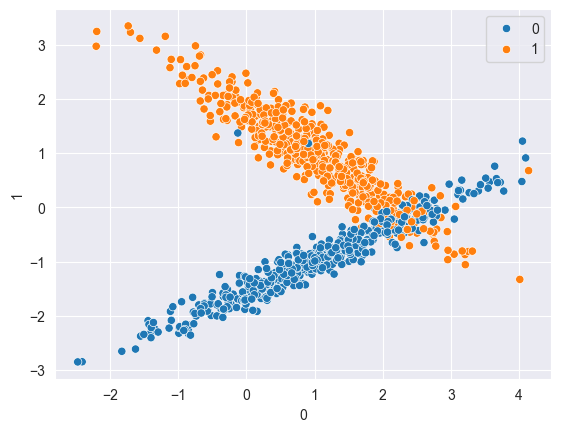

In [9]:
sns.scatterplot(x=X[0],y=X[1],hue=y)

In [10]:
svc = SVC(kernel='linear')

In [11]:
svc.fit(X_train,y_train)


SVC(kernel='linear')

In [12]:
y_pred = svc.predict(X_test)

In [13]:
score = accuracy_score(y_pred,y_test)
report = classification_report(y_pred,y_test)
matrix = confusion_matrix(y_pred,y_test)
print(score)
print(report)
print(matrix)

0.925
              precision    recall  f1-score   support

           0       0.99      0.88      0.93       117
           1       0.85      0.99      0.92        83

    accuracy                           0.93       200
   macro avg       0.92      0.93      0.92       200
weighted avg       0.93      0.93      0.93       200

[[103  14]
 [  1  82]]


# SVM USING DIFFERENT KERNELS

In [14]:
X,y = make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0,random_state=42)

In [15]:
X = pd.DataFrame(X)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

<Axes: xlabel='0', ylabel='1'>

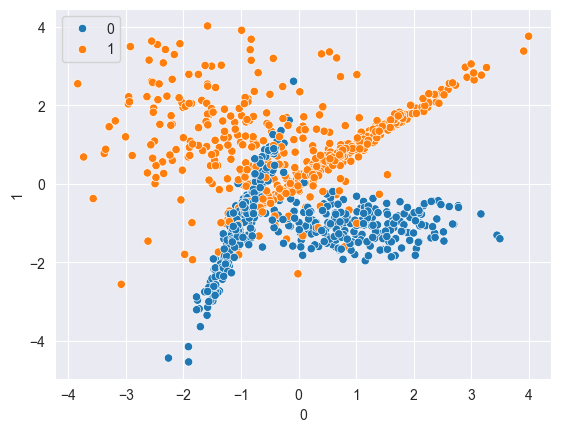

In [16]:
sns.scatterplot(x=X[0],y=X[1],hue=y)

In [17]:
kernels = ['linear','poly','rbf','sigmoid']
for kernel in kernels:
    svc = SVC(kernel=kernel)
    svc.fit(X_train,y_train)
    y_pred = svc.predict(X_test)
    score = accuracy_score(y_pred,y_test)
    report = classification_report(y_pred,y_test)
    matrix = confusion_matrix(y_pred,y_test)
    print(kernel)
    print(score)
    print(report)

linear
0.88
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       101
           1       0.88      0.88      0.88        99

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.88      0.88       200

poly
0.88
              precision    recall  f1-score   support

           0       0.82      0.93      0.87        89
           1       0.94      0.84      0.89       111

    accuracy                           0.88       200
   macro avg       0.88      0.89      0.88       200
weighted avg       0.89      0.88      0.88       200

rbf
0.9
              precision    recall  f1-score   support

           0       0.94      0.87      0.90       109
           1       0.86      0.93      0.89        91

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90 

# HYPER-PARAMETER TUNING

In [18]:
params = {
    'C':[0.01,0.1,10,100],
    'gamma':[0.01,0.1,1,10,100],
    'kernel':['rbf','sigmoid'],
    'tol':[1e-4,1-5,1e-5,1e-6]
}

In [19]:
grid = GridSearchCV(estimator=SVC(),param_grid=params,cv=5,verbose=3,refit=True,n_jobs=-1)
randomcv = RandomizedSearchCV(estimator=SVC(),param_distributions=params,cv=5,verbose=3,refit=True,n_jobs=-1)
hpt = [grid,randomcv]

In [20]:
for i in hpt:
    i.fit(X_train,y_train)
    print(i.best_params_)
    y_pred = i.predict(X_test)
    score = accuracy_score(y_pred,y_test)
    report = classification_report(y_pred,y_test)
    matrix = confusion_matrix(y_pred,y_test)
    print(score)
    print(report)
    print(matrix)

Fitting 5 folds for each of 160 candidates, totalling 800 fits
[CV 3/5] END C=0.01, gamma=0.01, kernel=rbf, tol=0.0001;, score=0.506 total time=   0.0s
[CV 1/5] END C=0.01, gamma=0.01, kernel=rbf, tol=1e-05;, score=0.500 total time=   0.0s
[CV 2/5] END C=0.01, gamma=0.01, kernel=rbf, tol=1e-05;, score=0.500 total time=   0.0s
[CV 3/5] END C=0.01, gamma=0.01, kernel=rbf, tol=1e-05;, score=0.506 total time=   0.0s
[CV 4/5] END C=0.01, gamma=0.01, kernel=rbf, tol=0.0001;, score=0.506 total time=   0.0s
[CV 4/5] END C=0.01, gamma=0.01, kernel=rbf, tol=1e-05;, score=0.506 total time=   0.0s
[CV 2/5] END C=0.01, gamma=0.01, kernel=rbf, tol=0.0001;, score=0.500 total time=   0.0s
[CV 5/5] END C=0.01, gamma=0.01, kernel=rbf, tol=1e-05;, score=0.506 total time=   0.0s
[CV 1/5] END C=0.01, gamma=0.01, kernel=rbf, tol=1e-06;, score=0.500 total time=   0.0s
[CV 2/5] END C=0.01, gamma=0.01, kernel=rbf, tol=1e-06;, score=0.500 total time=   0.0s
[CV 3/5] END C=0.01, gamma=0.01, kernel=rbf, tol=1e-06

/Users/kalp/PycharmProjects/Machine_learning/.venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
200 fits failed out of a total of 800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
200 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/kalp/PycharmProjects/Machine_learning/.venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/kalp/PycharmProjects/Machine_learning/.venv/lib/python3.9/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/Users/kalp/PycharmProjects/Machine_learning/.venv/lib/python3.9/si

In [21]:
grid.best_params_

{'C': 100, 'gamma': 1, 'kernel': 'rbf', 'tol': 0.0001}